<a href="https://colab.research.google.com/github/prostudentme-lang/GENERAL-HEALTH-PREDICTION/blob/main/GeneralHealthPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/CVD_cleaned.csv")
data.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [ ]:
le = LabelEncoder()
for col in data.columns:
  if data[col].dtype == 'object':
      data[col] = le.fit_transform(data[col])

In [ ]:
X = data.drop("Heart_Disease", axis=1)
y = data["Heart_Disease"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (247083, 18)
Testing samples: (61771, 18)


In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=5000)
svm.fit(X_train, y_train)


LinearSVC(max_iter=5000)

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
models = {
"Logistic Regression": lr,
"SVM": svm,
"Random Forest": rf
}

accuracies = {}

for name, model in models.items():
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  accuracies[name] = acc

print("\n", "="*40)
print(name)
print("Accuracy:", acc)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Random Forest
Accuracy: 0.9184892587136358
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56774
           1       0.45      0.03      0.06      4997

    accuracy                           0.92     61771
   macro avg       0.68      0.51      0.51     61771
weighted avg       0.88      0.92      0.88     61771

Confusion Matrix:
 [[56577   197]
 [ 4838   159]]


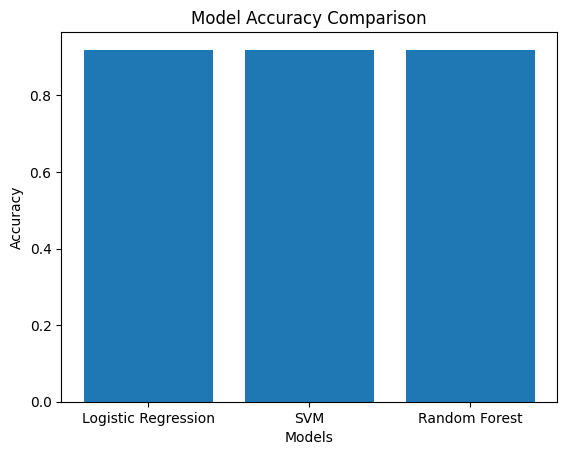

In [ ]:
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
param_grid = {
"n_estimators": [50, 100, 200],
"max_depth": [None, 10, 20, 30],
"min_samples_split": [2, 5, 10]
}

rf_random = RandomizedSearchCV(
RandomForestClassifier(),
param_grid,
n_iter=10,
cv=3,
random_state=42
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None}


In [ ]:
# Sample input (must match dataset order)
sample_input = np.array([[
2, 1, 1, 0, 0, 0, 0, 0,
1, 4, 170, 70, 24.2,
0, 2, 10, 8, 3
]])

prediction = rf_random.best_estimator_.predict(sample_input)

if prediction[0] == 1:
  print("AI Prediction: Person has Heart Disease")
else:
  print("AI Prediction: Person is Healthy")

AI Prediction: Person is Healthy


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
